In [1]:
'''
added more layers that in Rev2 to make more comparable to the transformer version 
'''

'\nadded more layers that in Rev2 to make more comparable to the transformer version \n'

In [2]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem


def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
#             print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
#     print(valid_dirs)
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


def mean_std_of_not_too_low(x,rtol=0.1):
    ref = np.max(x)
    ii = x>ref*(1-rtol)
    if not np.all(ii):
        print('WARNING, some runs discarded:', ii)
    return np.mean(x[ii]), np.std(x[ii]), np.sum(ii), sem(x[ii])

In [3]:
#rev2: changed datasets related to FMNIST for ones with vertical move 
#(results still reflect the horizontal move only, but on datasets that contain both)

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [5]:
ds_LUT = {'20240623':{'ds':'MNIST', 'dist':'D1'},}
#           '20240707':{'ds':'MNIST', 'dist':'D2'},
#           '20240801':{'ds':'FMNIST', 'dist':'D1'}, #change in rev2
#           '20240728':{'ds':'FMNIST', 'dist':'D2'}, #change in rev2
#           '20240703':{'ds':'KMNIST', 'dist':'D1'},
#           '20240705':{'ds':'KMNIST', 'dist':'D2'},
#          }

In [6]:
frames_LUT ={('MNIST','D1'): 0.882,
             ('MNIST','D2'): 0.664,
             ('FMNIST','D1'): 0.813,
             ('FMNIST','D2'): 0.725,
             ('KMNIST','D1'): 0.830,
             ('KMNIST','D2'): 0.666,
            }

In [7]:
min_epoch = 0
use_test = True
search_path = '../wexac_saved_runs/'

ref_config_paths = {'full_table':'../wexac_saved_runs/mnist_gru_match2__221680/config.yaml',
                      }

config_ignore_fields_s = {'full_table':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path', 'job_id']
                          }
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')

found 35 runs for mode full_table


In [8]:
def squeeze_dict(d):
    return d[[k for k in d.keys()][0]]

In [9]:
df = squeeze_dict(dfs)

In [10]:
n_samples_s = df['ds_args_n_samples'].unique()
data_paths = df['eb_ds_path'].unique()

In [11]:
dd = {}
for n_samples in n_samples_s:
    for data_path in data_paths:
        dd[(data_path.split('/')[-1],n_samples )] = \
        df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
        aggregate({'test_acc':[lambda x: mean_std_of_not_too_low(x)[0],
                               lambda x: mean_std_of_not_too_low(x)[1],
                               lambda x: mean_std_of_not_too_low(x)[2],
                                lambda x: mean_std_of_not_too_low(x)[3]]+ ['median','mean','std','sem']})

WARNING, some runs discarded: mnist_gru_match2__221723     True
mnist_gru_match2__221713    False
mnist_gru_match2__221701     True
mnist_gru_match2__221690    False
mnist_gru_match2__221680    False
Name: test_acc, dtype: bool
WARNING, some runs discarded: mnist_gru_match2__221723     True
mnist_gru_match2__221713    False
mnist_gru_match2__221701     True
mnist_gru_match2__221690    False
mnist_gru_match2__221680    False
Name: test_acc, dtype: bool
WARNING, some runs discarded: mnist_gru_match2__221723     True
mnist_gru_match2__221713    False
mnist_gru_match2__221701     True
mnist_gru_match2__221690    False
mnist_gru_match2__221680    False
Name: test_acc, dtype: bool
WARNING, some runs discarded: mnist_gru_match2__221723     True
mnist_gru_match2__221713    False
mnist_gru_match2__221701     True
mnist_gru_match2__221690    False
mnist_gru_match2__221680    False
Name: test_acc, dtype: bool
WARNING, some runs discarded: mnist_gru_match2__221681     True
mnist_gru_match2__221724

/tmp/ipykernel_1706132/1786313057.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1706132/1786313057.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1706132/1786313057.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1706132/1786313057.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1706132/1786313057.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1706132/1786313057.py:5: 

In [12]:
dd

{('20240623',
  96):           test_acc
 <lambda>  0.860940
 <lambda>  0.001826
 <lambda>  5.000000
 <lambda>  0.000913
 median    0.861700
 mean      0.860940
 std       0.002042
 sem       0.000913,
 ('20240623',
  8):           test_acc
 <lambda>  0.264550
 <lambda>  0.003050
 <lambda>  2.000000
 <lambda>  0.003050
 median    0.233000
 mean      0.227320
 std       0.047778
 sem       0.021367,
 ('20240623',
  48):           test_acc
 <lambda>  0.799440
 <lambda>  0.002611
 <lambda>  5.000000
 <lambda>  0.001306
 median    0.798000
 mean      0.799440
 std       0.002919
 sem       0.001306,
 ('20240623',
  16):           test_acc
 <lambda>  0.521400
 <lambda>  0.015600
 <lambda>  2.000000
 <lambda>  0.015600
 median    0.436500
 mean      0.405380
 std       0.150317
 sem       0.067224,
 ('20240623',
  32):           test_acc
 <lambda>  0.743120
 <lambda>  0.005561
 <lambda>  5.000000
 <lambda>  0.002781
 median    0.741300
 mean      0.743120
 std       0.006218
 sem       0.0027

In [13]:
df_prep = []

for ds_date,ds in ds_LUT.items():
    for n_samples in n_samples_s:
        df_prep.append([ds['ds'], ds['dist'], n_samples,
                        f'{dd[(ds_date,n_samples)].iloc[0,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[1,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[2,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[3,0]:.3f}',
                        ds_date])

In [14]:
dd[(ds_date,n_samples)]

,test_acc
<lambda>,0.827660
<lambda>,0.003471
<lambda>,5.000000
<lambda>,0.001736
median,0.826900
mean,0.827660
std,0.003881
sem,0.001736


In [15]:
dfsum = pd.DataFrame(df_prep, columns = ['Dataset', 'Distance', 'n_events' ,'AccMean','AccStd','AccCnt','AccSem','Date'])

In [16]:
dfsum = dfsum.sort_values(by=['n_events'])

In [17]:
dfsum

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem,Date
1,MNIST,D1,8,0.265,0.003,2.000,0.003,20240623
3,MNIST,D1,16,0.521,0.016,2.000,0.016,20240623
4,MNIST,D1,32,0.743,0.006,5.000,0.003,20240623
2,MNIST,D1,48,0.799,0.003,5.000,0.001,20240623
6,MNIST,D1,64,0.828,0.003,5.000,0.002,20240623
0,MNIST,D1,96,0.861,0.002,5.000,0.001,20240623
5,MNIST,D1,128,0.875,0.003,5.000,0.002,20240623


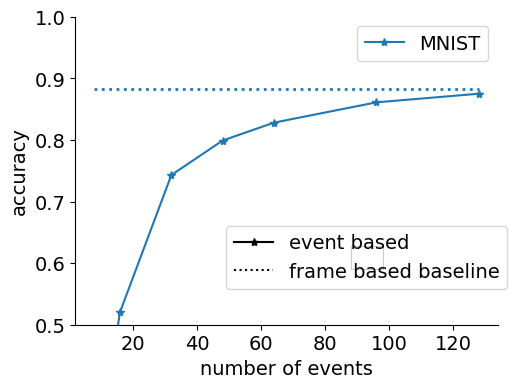

In [18]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 14})

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
    for dd,this_dist in enumerate(ddd):
        plt.subplot(1,2,dd+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
        
        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

        plt.plot(uu['n_events'].astype(float).to_numpy(),uu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds)
        fb_baseline = frames_LUT[(this_ds,this_dist)]
        plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
                 ':', linewidth=2,
                 color=color)

        plt.xlabel('number of events')
        plt.ylim(0.5,1.0)
        ax = plt.gca()

        ax.spines[['right', 'top']].set_visible(False)
plt.legend()
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
plt.subplot(1,2,1)
plt.ylabel('accuracy')
ax = plt.gca()

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
                       titles = ['event based', 'frame based baseline'] ,
                       bbox=(0.25,0.15,0.5,0.5))


/tmp/ipykernel_1706132/2614954974.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=1)


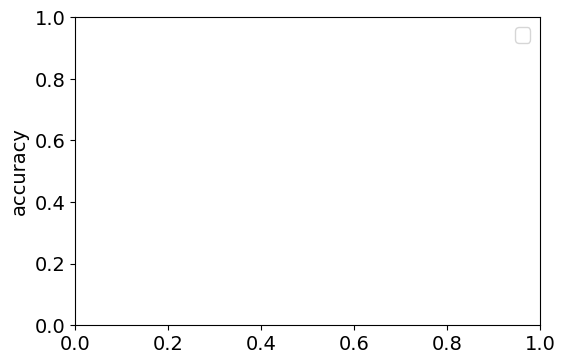

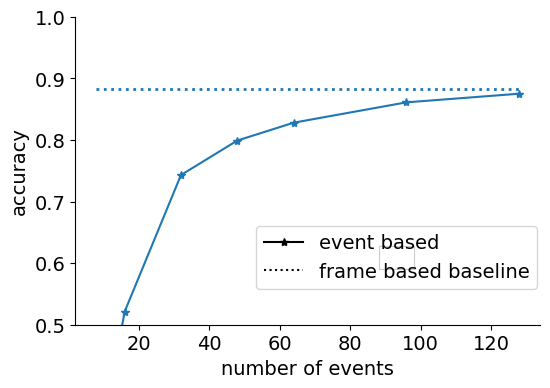

In [19]:
plt.figure(1,figsize=(6,4))
plt.rcParams.update({'font.size': 14})

plt.figure(2,figsize=(6,4))
plt.rcParams.update({'font.size': 14})

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
    for dd,this_dist in enumerate(ddd):
        plt.figure(dd+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
        
        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

        plt.plot(uu['n_events'].astype(float).to_numpy(),uu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds)
        fb_baseline = frames_LUT[(this_ds,this_dist)]
        plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
                 ':', linewidth=2,
                 color=color)

        plt.xlabel('number of events')
        plt.ylabel('accuracy')       
        plt.ylim(0.5,1.0)
        ax = plt.gca()

        ax.spines[['right', 'top']].set_visible(False)

plt.figure(2)

plt.legend(loc=1)
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
# plt.subplot(1,2,1)
plt.ylabel('accuracy')

plt.figure(1)
ax = plt.gca()

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
                       titles = ['event based', 'frame based baseline'] ,
                       bbox=(0.25,0.15,0.5,0.5))

In [20]:
dfsum.loc[dfsum['Dataset']=='FMNIST']

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem,Date


In [21]:
dfsum.loc[:,dfsum.columns != 'Date']

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem
1,MNIST,D1,8,0.265,0.003,2.000,0.003
3,MNIST,D1,16,0.521,0.016,2.000,0.016
4,MNIST,D1,32,0.743,0.006,5.000,0.003
2,MNIST,D1,48,0.799,0.003,5.000,0.001
6,MNIST,D1,64,0.828,0.003,5.000,0.002
0,MNIST,D1,96,0.861,0.002,5.000,0.001
5,MNIST,D1,128,0.875,0.003,5.000,0.002


In [22]:
dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]]

,Dataset,Distance,n_events,AccCnt,AccMean,AccStd,AccSem
1,MNIST,D1,8,2.000,0.265,0.003,0.003
3,MNIST,D1,16,2.000,0.521,0.016,0.016
4,MNIST,D1,32,5.000,0.743,0.006,0.003
2,MNIST,D1,48,5.000,0.799,0.003,0.001
6,MNIST,D1,64,5.000,0.828,0.003,0.002
0,MNIST,D1,96,5.000,0.861,0.002,0.001
5,MNIST,D1,128,5.000,0.875,0.003,0.002


In [23]:
import pandas as pd

def df_to_latex_table(df: pd.DataFrame, new_column_names: dict = None, column_formats: dict = None, default_format: str = ".3f") -> str:
    """
    Convert a pandas DataFrame to a LaTeX table string with optional column renaming, formatting, and multi-line headers.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        new_column_names (dict, optional): A dictionary to rename columns. 
                                           Format: {'old_name': 'new_name'}.
        column_formats (dict, optional): A dictionary specifying format for columns.
                                         Format: {'column_name': 'format_specifier'}.
                                         Example: {'A': '.2f', 'B': 'd'}.
        default_format (str, optional): Default formatting for numeric values. Defaults to '.3f'.
                                           
    Returns:
        str: Full LaTeX code for the table.
    """
    def try_convert_to_number(value):
        """Try to convert a value to a number if it looks like one."""
        try:
            return float(value) if '.' in str(value) else int(value)
        except ValueError:
            return value

    def format_header(header):
        """Format a column header to split long text into multiple lines using \makecell."""
        return "\\makecell{" + " \\\\ ".join(header.split()) + "}"

    # Rename columns if new_column_names is provided
    if new_column_names:
        df = df.rename(columns=new_column_names)
    
    # Apply formatting to columns if column_formats is provided
    formatted_df = df.copy()
    for col in formatted_df.columns:
        if column_formats and col in column_formats:
            fmt = column_formats[col]
        else:
            fmt = default_format  # Use default format for unspecified columns
        
        formatted_df[col] = formatted_df[col].apply(
            lambda x: f"{try_convert_to_number(x):{fmt}}" 
                      if pd.notnull(x) and isinstance(try_convert_to_number(x), (int, float)) 
                      else x
        )
    
    # Start the LaTeX table
    latex_code = "\\begin{table}[ht]\n\\centering\n"
    latex_code += "\\begin{tabular}{" + " | ".join(["c"] * len(formatted_df.columns)) + "}\n"
    latex_code += "\\hline\n"
    
    # Add column headers with multi-line formatting
    formatted_headers = [format_header(header) for header in formatted_df.columns]
    latex_code += " & ".join(formatted_headers) + " \\\\\n"
    latex_code += "\\hline\n"
    
    # Add rows
    for _, row in formatted_df.iterrows():
        latex_code += " & ".join(map(str, row)) + " \\\\\n"
        latex_code += "\\hline\n"
    
    # End the LaTeX table
    latex_code += "\\end{tabular}\n"
    latex_code += "\\caption{Your table caption here.}\n"
    latex_code += "\\label{tab:your_label_here}\n"
    latex_code += "\\end{table}"
    
    return latex_code


In [24]:
print(
    df_to_latex_table(dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]],
                     column_formats={'AccCnt':'.0f'})
)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c}
\hline
\makecell{Dataset} & \makecell{Distance} & \makecell{n_events} & \makecell{AccCnt} & \makecell{AccMean} & \makecell{AccStd} & \makecell{AccSem} \\
\hline
MNIST & D1 & 8.000 & 2 & 0.265 & 0.003 & 0.003 \\
\hline
MNIST & D1 & 16.000 & 2 & 0.521 & 0.016 & 0.016 \\
\hline
MNIST & D1 & 32.000 & 5 & 0.743 & 0.006 & 0.003 \\
\hline
MNIST & D1 & 48.000 & 5 & 0.799 & 0.003 & 0.001 \\
\hline
MNIST & D1 & 64.000 & 5 & 0.828 & 0.003 & 0.002 \\
\hline
MNIST & D1 & 96.000 & 5 & 0.861 & 0.002 & 0.001 \\
\hline
MNIST & D1 & 128.000 & 5 & 0.875 & 0.003 & 0.002 \\
\hline
\end{tabular}
\caption{Your table caption here.}
\label{tab:your_label_here}
\end{table}


In [25]:
!cat  ../wexac_saved_runs/mnist_gru_match2__221680/run.log

Namespace(config_file='config/config_hA07.yaml', run_name='mnist_gru_match2__221680', job_id_suffix='', tag='gru_sweep_match2', model='TimeSeriesGRU', model_args_model_head='cls_avgpool', model_args_n_layers=14, eb_ds_path='../../../bnassa/event_based_drc/dataset/20240623', ds_train_subdir='train', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=8, use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_no_head=False, train_head_only=False, eval=True, flatten_contrastive_input=False, check_job_recovery=True, disable_data_parallel=False, eb_ds_time_align_by_imu_edge=False, ds_args_one_hot_coordinates=False, en_autodetect_offsets=False, save_path='./saved_runs/', model_args_dropout_rate=0.1, model_args_d_timeseries=4, model_args_num_classes=10, model_args_offsets=[[[-110, -35, -26, 0]]], model_args_scalings=[[[0.1, 1.0, 1.0, 1.0]]], dataset='eb_ds', num_workers=4, n_validation=6000, ds_args_shuffle_events=False, ds_args_train_from_time_interval=[70, 180], ds

In [26]:
!cat  ../wexac_saved_runs/mnist_gru_match2__221680/config.yaml

batch_size: 64
check_job_recovery: true
config_file: config/config_hA07.yaml
dataset: eb_ds
disable_data_parallel: false
do_warmup: true
ds_args_n_samples: 8
ds_args_one_hot_coordinates: false
ds_args_shuffle_events: false
ds_args_train_from_time_interval:
- 70
- 180
ds_args_val_start_time: 100
ds_test_subdir: test
ds_train_subdir: train
eb_ds_path: ../../../bnassa/event_based_drc/dataset/20240623
eb_ds_time_align_by_imu_edge: false
eb_ds_ts_jitter: 0.0
en_autodetect_offsets: false
epochs: 100
eval: true
flatten_contrastive_input: false
job_id: '221680'
job_id_suffix: ''
json_log: ./saved_runs/mnist_gru_match2__221680/results/epoch_data.json
json_test_data: ./saved_runs/mnist_gru_match2__221680/results/test_data.json
lr: 0.0001
model: TimeSeriesGRU
model_args_d_timeseries: 4
model_args_dropout_rate: 0.1
model_args_model_head: cls_avgpool
model_args_n_layers: 14
model_args_num_classes: 10
model_args_offsets:
- - - -110
    - -35
    - -26
    - 0
model_args_scalings:
- - - 0.1
    - 1.0

In [27]:
dfsum_transformer = pd.read_csv('accs_over_events_and_baselinses.csv')
dfsum_transformer = dfsum_transformer.loc[dfsum_transformer['Dataset']=='MNIST']
dfsum_transformer = dfsum_transformer.loc[dfsum_transformer['Distance']=='D1']


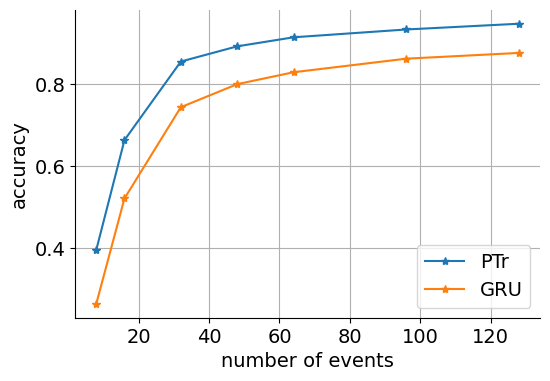

In [30]:
plt.figure(1,figsize=(6,4))
plt.rcParams.update({'font.size': 14})
for this_df in [dfsum_transformer,dfsum]:
    plt.plot(this_df['n_events'].astype(float),this_df['AccMean'].astype(float),'-*')

plt.xlabel('number of events')
plt.ylabel('accuracy')       
# plt.ylim(0.5,1.0)
plt.grid()
ax = plt.gca()
plt.legend(['PTr','GRU'])

ax.spines[['right', 'top']].set_visible(False)
plt.savefig('figS1panelA.svg',format='svg')

In [31]:
dfsum_transformer.to_csv(f'figS1panelA_PTr.csv')
dfsum.to_csv(f'figS1panelA_GRU.csv')